In [3]:
import pandas as pd
import numpy as np

DATA_PATH = "../data/UCI_dataset/"

X_train = pd.read_csv(DATA_PATH + "train/X_train.txt", sep=r'\s+', header=None).values
X_test  = pd.read_csv(DATA_PATH + "test/X_test.txt",  sep=r'\s+', header=None).values

y_train = pd.read_csv(DATA_PATH + "train/y_train.txt", header=None).values.flatten()
y_test  = pd.read_csv(DATA_PATH + "test/y_test.txt",  header=None).values.flatten()


labels_df = pd.read_csv(DATA_PATH + "activity_labels.txt", sep=' ', header=None)
LABELS = labels_df[1].tolist()

print("X_train shape:", X_train.shape)
print("X_test shape:",  X_test.shape)
print("Activités:", LABELS)

X_train shape: (7352, 561)
X_test shape: (2947, 561)
Activités: ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']


In [4]:
print(np.unique(y_train))

[1 2 3 4 5 6]


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Input



# begin from 0-5
y_train = y_train - 1
y_test  = y_test  - 1

# One-hot encoding ex : 2= [0, 0, 1, 0, 0, 0] vector in R^num_classes
y_train_cat = to_categorical(y_train, num_classes=6)
y_test_cat  = to_categorical(y_test,  num_classes=6)


# Reshape for LSTM : (samples, timesteps, features)
X_train_lstm = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test_lstm  = X_test.reshape(X_test.shape[0],   1, X_test.shape[1])


model1 = Sequential([
    Input(shape=(1, 561)),
    LSTM(64, return_sequences=True),
    Dropout(0.3),
    LSTM(64),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(6, activation='softmax')
])

model2 = Sequential([
    Input(shape=(1, 561)),
    LSTM(128),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(6, activation='softmax')
])



model1.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

I0000 00:00:1781034464.531838  261198 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781034464.532770  261198 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781034464.572393  261198 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781034465.407075  261198 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [6]:

def plot_curves(history):
    plt.figure(figsize=(12,8))

    plt.plot(history.history['loss'],     label='Train loss')
    plt.plot(history.history['accuracy'],     label='Train accuracy')

    plt.plot(history.history['val_loss'], label='Test loss')
    plt.plot(history.history['val_accuracy'], label='Test accuracy')

    plt.title("Training session's progress over iteration")
    plt.legend(loc = 'upper right', shadow = True)
    plt.ylabel('Training Progress(Loss or Accuracy values)')
    plt.xlabel('Training Epoch')
    plt.ylim(0)

    plt.show()



def plot_cm(model):
    y_pred = np.argmax(model.predict(X_test_lstm), axis=1)
    cm = metrics.confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=LABELS, yticklabels=LABELS)
    plt.title("Matrice de confusion")
    plt.xlabel("Prédit")
    plt.ylabel("Réel")
    plt.tight_layout()
    plt.savefig("confusion_matrix.png")
    plt.show()

In [7]:
history1 = model1.fit(
    X_train_lstm, y_train_cat,
    epochs=50,
    batch_size=1024,
    validation_data=(X_test_lstm, y_test_cat),
    verbose=1
)

loss1, acc1 = model1.evaluate(X_test_lstm, y_test_cat, verbose=0)
print(f"\nAccuracy : {acc1*100:.2f}%")
print(f"Loss : {loss1*100:.2f}%")

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.3168 - loss: 1.7439 - val_accuracy: 0.3349 - val_loss: 1.6285
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3754 - loss: 1.5499 - val_accuracy: 0.3855 - val_loss: 1.3680
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4361 - loss: 1.2973 - val_accuracy: 0.5114 - val_loss: 1.1190
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5675 - loss: 1.0731 - val_accuracy: 0.7027 - val_loss: 0.9136
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6885 - loss: 0.8772 - val_accuracy: 0.7598 - val_loss: 0.7313
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7659 - loss: 0.6940 - val_accuracy: 0.8188 - val_loss: 0.5716
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8101 - loss: 0.5445 - val_accuracy: 0.8096 - val_loss: 0.4745
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8415 - loss: 0.4362 - val_accuracy: 0.8459 - val_loss: 0.3634


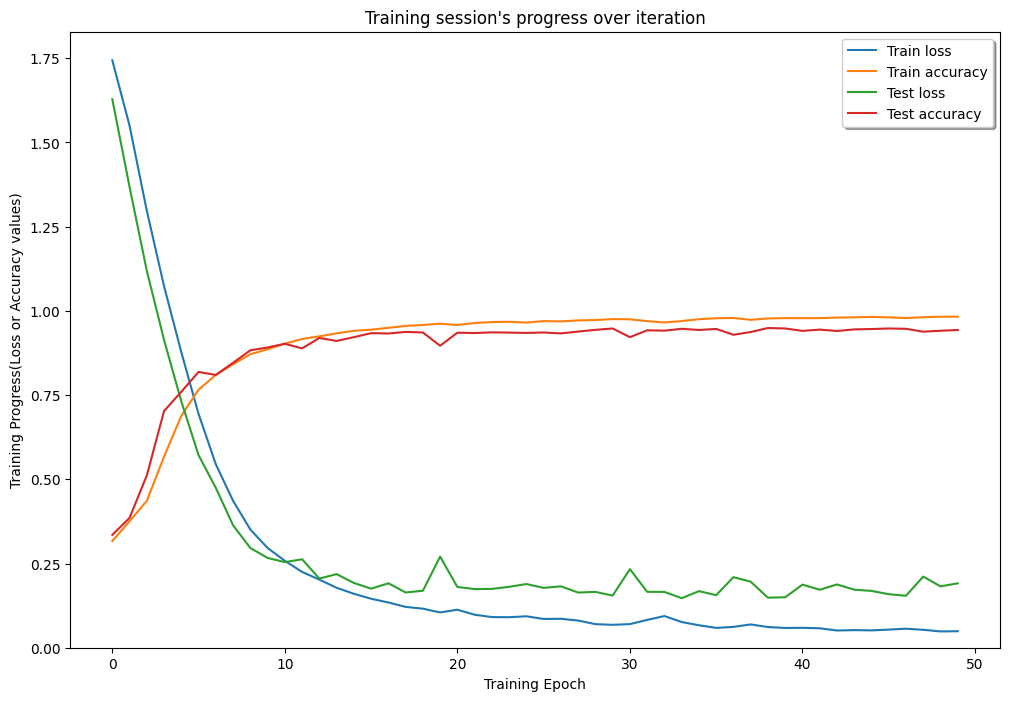

In [8]:
plot_curves(history=history1)

In [9]:
history2 = model2.fit(
    X_train_lstm, y_train_cat,
    epochs=300,
    batch_size=512,
    validation_data=(X_test_lstm, y_test_cat),
    verbose=1
)

loss2, acc2 = model2.evaluate(X_test_lstm, y_test_cat, verbose=0)
print(f"\nAccuracy : {acc2*100:.2f}%")
print(f"Loss : {loss2*100:.2f}%")

Epoch 1/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.5736 - loss: 1.1952 - val_accuracy: 0.7777 - val_loss: 0.7345
Epoch 2/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8131 - loss: 0.5711 - val_accuracy: 0.8514 - val_loss: 0.4279
Epoch 3/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8753 - loss: 0.3472 - val_accuracy: 0.9104 - val_loss: 0.2747
Epoch 4/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9124 - loss: 0.2442 - val_accuracy: 0.9097 - val_loss: 0.2348
Epoch 5/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9309 - loss: 0.1908 - val_accuracy: 0.9420 - val_loss: 0.1864
Epoch 6/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9415 - loss: 0.1585 - val_accuracy: 0.9277 - val_loss: 0.2001
Epoch 7/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9479 - loss: 0.1398 - val_accuracy: 0.9406 - val_loss: 0.1568
Epoch 8/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9606 - loss: 0.1140 - val_accuracy: 0.

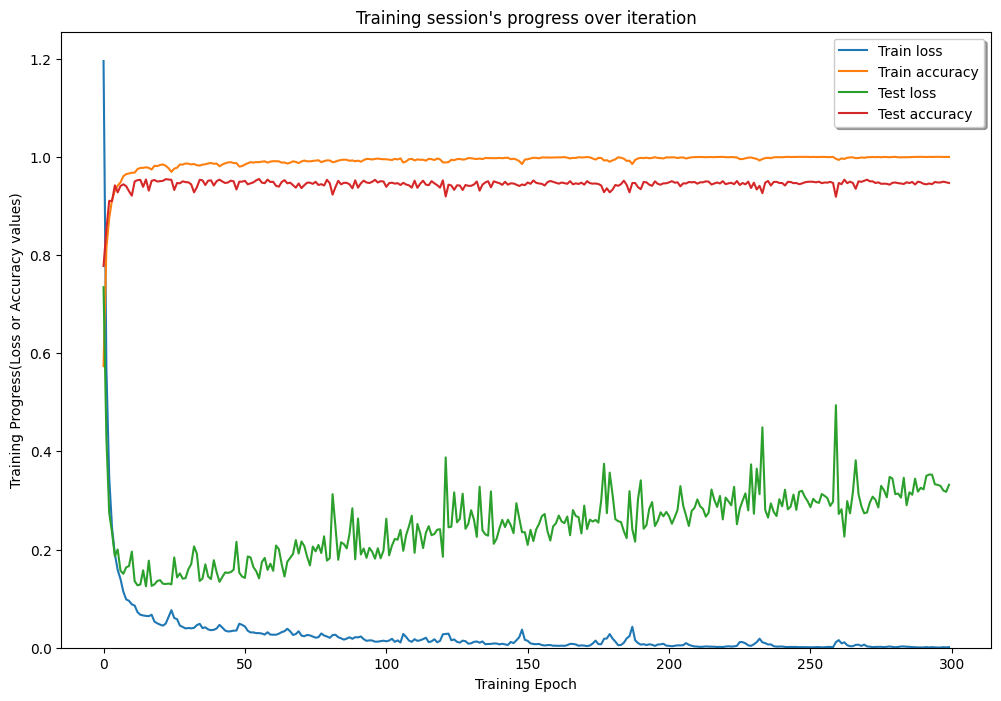

In [10]:
plot_curves(history=history2)

! Early stop !

In [11]:
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model3 = Sequential([
    LSTM(64, return_sequences=True, input_shape=(1, 561),
         kernel_regularizer=l2(0.001)),
    Dropout(0.4),
    LSTM(32, kernel_regularizer=l2(0.001)),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dense(6, activation='softmax')
])

model3.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history3 = model3.fit(
    X_train_lstm, y_train_cat,
    epochs=300,
    batch_size=256,
    validation_data=(X_test_lstm, y_test_cat),
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6)
    ],
    verbose=1
)

loss3, acc3 = model3.evaluate(X_test_lstm, y_test_cat, verbose=0)
print(f"\nAccuracy : {acc3*100:.2f}%")
print(f"Loss : {loss3*100:.2f}%")

Epoch 1/300


/home/hiba/HAR_models/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.2916 - loss: 2.0967 - val_accuracy: 0.3488 - val_loss: 1.9137 - learning_rate: 5.0000e-04
Epoch 2/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4138 - loss: 1.7763 - val_accuracy: 0.3868 - val_loss: 1.5288 - learning_rate: 5.0000e-04
Epoch 3/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5627 - loss: 1.4177 - val_accuracy: 0.7428 - val_loss: 1.1321 - learning_rate: 5.0000e-04
Epoch 4/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7210 - loss: 1.0777 - val_accuracy: 0.8273 - val_loss: 0.8236 - learning_rate: 5.0000e-04
Epoch 5/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7947 - loss: 0.8257 - val_accuracy: 0.8765 - val_loss: 0.6295 - learning_rate: 5.0000e-04
Epoch 6/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8390 - loss: 0.6621 - val_accuracy: 0.8785 - val_loss: 0.5140 - learning_rate: 5.0000e-04
Epoch 7/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8671 - loss: 0

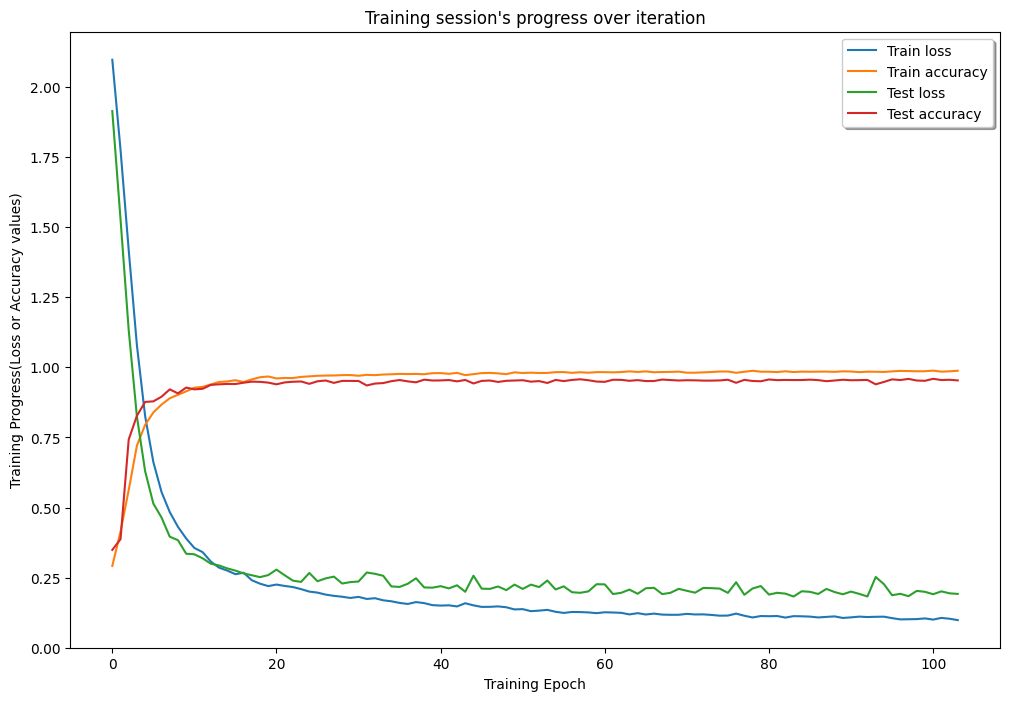

In [12]:
plot_curves(history=history3)

# CONV Models

In [13]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten

model_cnn = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(561, 1)),
    Conv1D(128, kernel_size=3, activation='relu', padding='same'),
    MaxPooling1D(pool_size=1),
    Dropout(0.4),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(6, activation='softmax')
])

model_cnn.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


X_train_cnn = X_train.reshape(-1, 561, 1)
X_test_cnn  = X_test.reshape(-1, 561, 1)

history_cnn = model_cnn.fit(
    X_train_cnn, y_train_cat,
    epochs=300,
    batch_size=256,
    validation_data=(X_test_cnn, y_test_cat),
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6)
    ],
    verbose=1
)

loss_cnn, acc_cnn = model_cnn.evaluate(X_test_cnn, y_test_cat, verbose=0)

print(f"\nAccuracy CNN : {loss_cnn*100:.2f}%")
print(f"Loss CNN : {acc_cnn*100:.2f}%")

Epoch 1/300


/home/hiba/HAR_models/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 189ms/step - accuracy: 0.7507 - loss: 0.6906 - val_accuracy: 0.8884 - val_loss: 0.2978 - learning_rate: 5.0000e-04
Epoch 2/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 228ms/step - accuracy: 0.9342 - loss: 0.1694 - val_accuracy: 0.9335 - val_loss: 0.1702 - learning_rate: 5.0000e-04
Epoch 3/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 222ms/step - accuracy: 0.9622 - loss: 0.1039 - val_accuracy: 0.9403 - val_loss: 0.1690 - learning_rate: 5.0000e-04
Epoch 4/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 238ms/step - accuracy: 0.9593 - loss: 0.0997 - val_accuracy: 0.9457 - val_loss: 0.1463 - learning_rate: 5.0000e-04
Epoch 5/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 233ms/step - accuracy: 0.9780 - loss: 0.0644 - val_accuracy: 0.9576 - val_loss: 0.1206 - learning_rate: 5.0000e-04
Epoch 6/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 227ms/step - accuracy: 0.9816 - loss: 0.0536 - val_accuracy: 0.9498 - val_loss: 0.1312 - learning_rate: 5.0000e-04
Epoch 7/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 229ms/step - accuracy: 0.984

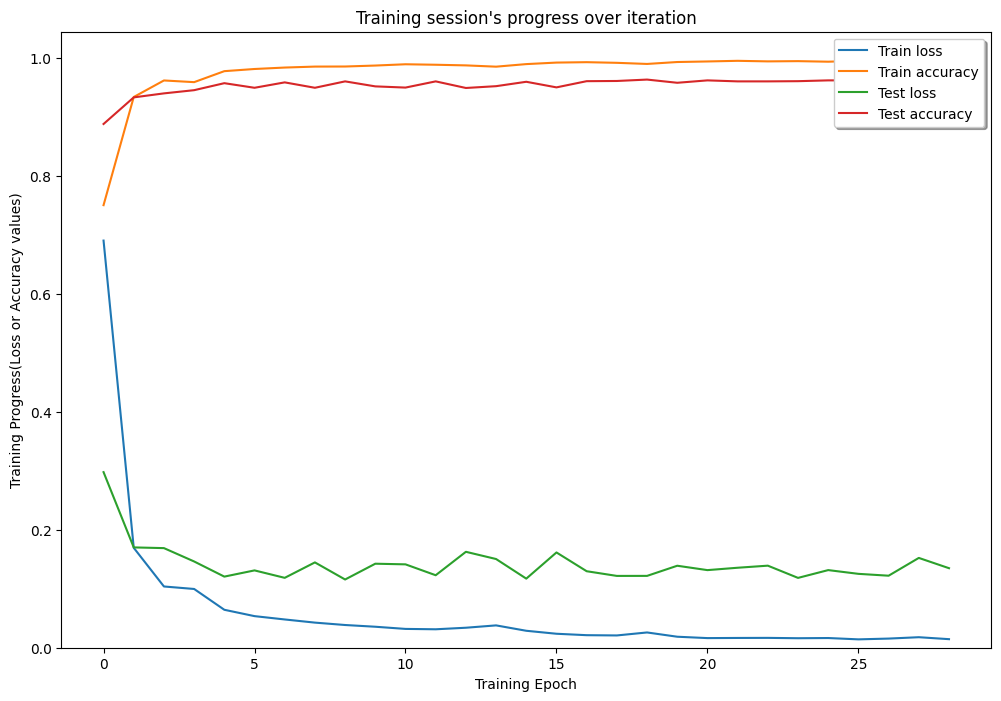

In [14]:
plot_curves(history=history_cnn)

In [18]:
model_cnn_lstm = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', 
           padding='same', input_shape=(561, 1)),
    Dropout(0.3),
    LSTM(64, return_sequences=True),
    LSTM(32),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dense(6, activation='softmax')
])



model_cnn_lstm.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_cnn_lstm = model_cnn_lstm.fit(
    X_train_cnn, y_train_cat,
    epochs=300,
    batch_size=256,
    validation_data=(X_test_cnn, y_test_cat),
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6)
    ],
    verbose=1
)

loss_cnn_lstm, acc_cnn_lstm = model_cnn_lstm.evaluate(X_test_cnn, y_test_cat, verbose=0)

print(f"\nAccuracy CNN : {acc_cnn_lstm*100:.2f}%")
print(f"Loss CNN : {loss_cnn_lstm*100:.2f}%")

Epoch 1/300


/home/hiba/HAR_models/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


29/29 ━━━━━━━━━━━━━━━━━━━━ 27s 877ms/step - accuracy: 0.2008 - loss: 1.7417 - val_accuracy: 0.2521 - val_loss: 1.5919 - learning_rate: 5.0000e-04
Epoch 2/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 25s 868ms/step - accuracy: 0.3088 - loss: 1.5572 - val_accuracy: 0.2348 - val_loss: 2.1986 - learning_rate: 5.0000e-04
Epoch 3/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 26s 893ms/step - accuracy: 0.3305 - loss: 1.4109 - val_accuracy: 0.3553 - val_loss: 1.2110 - learning_rate: 5.0000e-04
Epoch 4/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 25s 852ms/step - accuracy: 0.3417 - loss: 1.2202 - val_accuracy: 0.3414 - val_loss: 1.1477 - learning_rate: 5.0000e-04
Epoch 5/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 24s 831ms/step - accuracy: 0.3444 - loss: 1.1659 - val_accuracy: 0.3414 - val_loss: 1.1273 - learning_rate: 5.0000e-04
Epoch 6/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 23s 812ms/step - accuracy: 0.3342 - loss: 1.1908 - val_accuracy: 0.3403 - val_loss: 1.2436 - learning_rate: 5.0000e-04
Epoch 7/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 23s 801ms/step - accuracy

KeyboardInterrupt: 